# Lab 5 : Policy gradients and REINFORCE

In this lab you will implement a neural network policy on the cartpole environment

## Imports and Helper functions

In [1]:
!pip install gymnasium
!pip install torch
!pip install 'typing-extensions>=4.3.0'

In [2]:
import torch
from torch import nn
from torch.nn.functional import one_hot

import numpy as np
from matplotlib import pyplot as plt
import gymnasium as gym

from collections import namedtuple

### Helper functions

In [3]:
#@title Helper code: Episode Logging
# Book keeping of some useful (episode) statistics
Logging_EpStats = namedtuple("Logging_EpStats",
                             ["episode_lengths", "episode_rewards"])

# We are going to be storing transitions encountered in the episode to use
# later in the update (at the end of the episode, for REINFORCE)
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "discount"])

def plot_stats(stats, window=10):
  plt.figure(figsize=(16,4))
  plt.subplot(121)
  xline = range(0, len(stats.episode_lengths), window)
  plt.plot(xline, smooth(stats.episode_lengths, window=window))
  plt.ylabel('Episode Length')
  plt.xlabel('Episode Count')
  plt.subplot(122)
  plt.plot(xline, smooth(stats.episode_rewards, window=window))
  plt.ylabel('Episode Return')
  plt.xlabel('Episode Count')

def smooth(x, window=10):
  return x[:window*(len(x)//window)].reshape(len(x)//window, window).mean(axis=1)


### neural network helper fns

In [4]:
def get_activation(
    activation: str,
) -> type[nn.Identity | nn.ReLU | nn.Sigmoid | nn.Softplus | nn.Tanh | nn.Softmax]:
    """Get the activation function.

    The ``activation`` can be chosen from: ``identity``, ``relu``, ``sigmoid``, ``softplus``,
    ``tanh``.

    Args:
        activation (Activation): The activation function.

    Returns:
        The activation function, ranging from ``nn.Identity``, ``nn.ReLU``, ``nn.Sigmoid``,
        ``nn.Softplus`` to ``nn.Tanh``.
    """
    activations = {
        'identity': nn.Identity,
        'relu': nn.ReLU,
        'sigmoid': nn.Sigmoid,
        'softplus': nn.Softplus,
        'tanh': nn.Tanh,
        'softmax': nn.Softmax
    }
    assert activation in activations
    return activations[activation]

In [5]:
def build_mlp_network(
    sizes: list[int],
    activation: str = 'tanh',
    output_activation: str = 'identity',
) -> nn.Module:

    """Build the MLP network.

    Examples:
        >>> build_mlp_network([64, 64, 64], 'relu', 'tanh')
        Sequential(
            (0): Linear(in_features=64, out_features=64, bias=True)
            (1): ReLU()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): ReLU()
            (4): Linear(in_features=64, out_features=64, bias=True)
            (5): Tanh()
        )

    Args:
        sizes (list of int): The sizes of the layers.
        activation (Activation): The activation function.
        output_activation (Activation, optional): The output activation function. Defaults to
            ``identity``.
        weight_initialization_mode (InitFunction, optional): Weight initialization mode. Defaults to
            ``'kaiming_uniform'``.

    Returns:
        The MLP network.
    """
    activation_fn = get_activation(activation)
    output_activation_fn = get_activation(output_activation)
    layers = []
    for j in range(len(sizes) - 1):
        act_fn = activation_fn if j < len(sizes) - 2 else output_activation_fn
        affine_layer = nn.Linear(sizes[j], sizes[j + 1])
        # initialize_layer(weight_initialization_mode, affine_layer)
        layers += [affine_layer, act_fn()]
    return nn.Sequential(*layers)

## 1. REINFORCE

### 1.1 [Derivation Task, 10 points] Gradient of softmax policy

We will consider neural network policies given by arbitrary hidden layers and activations, and with a softmax layer at the end.

In that way, our policy looks like:
$$\pi(a|s) = \frac{\exp(\phi(s,a))}{\sum_{a'\in\mathcal{A}}\exp(\phi(s,a'))},$$

where $\phi$ is the Neural Network (before the softmax activation.

**Task:**
For given (s,a), get a closed form solution for
$$\nabla\log\pi(a|s)$$



**Your answer:**

from softmax：

$$\log\pi(a|s) = \phi(s,a) - \log\sum_{a'\in\mathcal{A}}\exp(\phi(s,a'))$$

calulate $\theta$ gradient. First term $\nabla\phi(s,a)$；sencond term：

$$\nabla\log\sum_{a'}\exp(\phi(s,a')) = \frac{\sum_{a'}\exp(\phi(s,a'))\,\nabla\phi(s,a')}{\sum_{a'}\exp(\phi(s,a'))} = \sum_{a'}\pi(a'|s)\,\nabla\phi(s,a')$$

so：

$$\nabla\log\pi(a|s) = \nabla\phi(s,a) - \sum_{a'\in\mathcal{A}}\pi(a'|s)\,\nabla\phi(s,a') = \nabla\phi(s,a) - \mathbb{E}_{a'\sim\pi(\cdot|s)}[\nabla\phi(s,a')]$$



### 1.2 [Coding task, 20 points]
Complete the highlighted methods for the PolicyApproximator class below.

In [6]:
class PolicyApproximator(torch.nn.Module):
    def __init__(self, state_dim: int, num_actions: int, hidden_sizes: list[int],
                 activation: str,
                 output_activation: str,
                 learning_rate: float):
        super().__init__()
        self.model = build_mlp_network(
            sizes=[state_dim, *hidden_sizes, num_actions],
            activation=activation,
            output_activation=output_activation,
        )

        self.lr = learning_rate
        self.optim = torch.optim.Adam(params=self.model.parameters(),
                                      lr=learning_rate)

    def get_probabilities(self, obs: torch.Tensor) -> torch.Tensor:
        probs = self.model(obs)
        probs = probs / probs.sum(dim=-1, keepdim=True)
        return probs

    def get_log_probs(self, s, a):
        # s: (n, O),  a: (n,)
        probs = self.get_probabilities(s)

        log_probs_all = torch.log(probs + 1e-8)

        return log_probs_all.gather(1, a.long().view(-1, 1)).squeeze(-1)

    def update(self, obs: torch.Tensor, target: torch.Tensor, action: torch.Tensor) -> None:
        self.optim.zero_grad()

        log_probs = self.get_log_probs(obs, action)       # shape (T,)
        # REINFORCE loss： -G * log pi(a|s)
        loss = -(target * log_probs).mean()

        loss.backward()
        self.optim.step()

        return loss.mean()

### 1.3 [Coding task, 20 points]
Complete the highlighted methods for the ReinforceAgent class below.

In [7]:
class REINFORCEAgent:
    def __init__(self, env: gym.Env, gamma: float, policy_params: dict):
        state = env.reset()

        state_dim = env.observation_space.shape[0]
        num_actions = env.action_space.n

        self.pi = PolicyApproximator(state_dim=state_dim,
                                     num_actions=num_actions,
                                     hidden_sizes=policy_params['hidden_sizes'],
                                     activation=policy_params['activation'],
                                     output_activation=policy_params['output_activation'],
                                     learning_rate=policy_params['learning_rate'],
                                    )
        self.gamma = gamma
        self._state = state
        self._action = 0

    def step(self, state):
        with torch.no_grad():
            probs = self.pi.get_probabilities(state.unsqueeze(0)).squeeze(0)
        # sample an action according to the probabilities
        dist = torch.distributions.Categorical(probs=probs)
        action = dist.sample().item()

        self._action = action
        self._state = state
        return self._action

    def update(self, episode: list) -> None:
        T = len(episode)
        if T == 0:
            return

        # propagate discounted return G_t
        returns = np.zeros(T, dtype=np.float32)
        G = 0.0
        for t in reversed(range(T)):
            r = episode[t][2]
            G = r + self.gamma * G
            returns[t] = G

        states  = torch.stack([torch.as_tensor(e[0], dtype=torch.float32) for e in episode])
        actions = torch.tensor([e[1] for e in episode], dtype=torch.long)
        G_t     = torch.tensor(returns, dtype=torch.float32)

        self.pi.update(states, G_t, actions)
        return

---

### Run experiment!
- Let's try it out!
- You can play around with the policy paremeters in the cell below

In [8]:
#@title [IMPORTANT] Run REINFORCE agent with an environment 'env'
# Description:
# Simple experiment run loop
# -----------------------------------------------------------------------------
# Expected behaviour
# 1) For each episode repeat:
#  - Interact with the environment (get observation and discount)
#  - Store transition
# 2) At the end of the episode, use the stored transition to update agent
# Repeat for num_episode
# -----------------------------------------------------------------------------
# Additional: Log and return episode stastics for plotting later on
# -----------------------------------------------------------------------------
def run_reinforce(env, agent, num_episodes,
                  MAXSTEPS_PER_EPISODE=100,
                  REPORT_EVERY_N_STEPS=20):
    """
    Run REINFORCE agent in a MDP especified by 'env'.
    (Any agent that follows the same logic and can be plugged in though.)

    Agent requirements:
      agent.step(state)
      agent.update(episode)

    Enviroment requirements:
      env.step(action)

    -----------------------------------------------------------------------
    Inputs:
        env: mountain car
        agent: REINFORCE agent (or alternative)
        num_episodes: Number of episodes to run for

    Returns:
        episode_statistics: list containing (episode_length & episode_reward) for each episode.
    """

    # Book-keeping of some useful (episode) statistics
    stats = Logging_EpStats(
    episode_lengths=np.zeros(num_episodes),
    episode_rewards=np.zeros(num_episodes))


    for i_episode in range(num_episodes):
        state, _ = env.reset()

        # Reset the environment and pick the first action
        action = agent.step(torch.Tensor(state))
        # print(f'sampled action {action}')
        # print(f'action has type {type(action)}')
        next_s, r, term, trunc, _ = env.step(int(action))
        # print(f'r is {r}')

        episode = []

        # One step in the environment
        state = next_s
        for t in range(MAXSTEPS_PER_EPISODE):

            # Take a step
            action = agent.step(torch.Tensor(state))
            # print(f'sampled action {action}')
            next_s, r, term, trunc, _ = env.step(int(action))

            # Keep track of the transition
            episode.append((state, action, r, next_s))

            # Optional: Logging and reporting (live) statistics for this epsiode

            # Update statistics
            stats.episode_rewards[i_episode] += r
            stats.episode_lengths[i_episode] = t

            done = term or trunc
            if done:
                break

            state = next_s

        # Make the policy update
        agent.update(episode)
    return stats

In [9]:
env = gym.make('CartPole-v1')
gamma = 0.99

policy_params = dict(
    hidden_sizes=[32],
    activation='relu',
    output_activation='softmax',
    learning_rate = 5e-4,
)

num_episodes = 1000
agent = REINFORCEAgent(env, gamma, policy_params)
stats = run_reinforce(env, agent, num_episodes)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


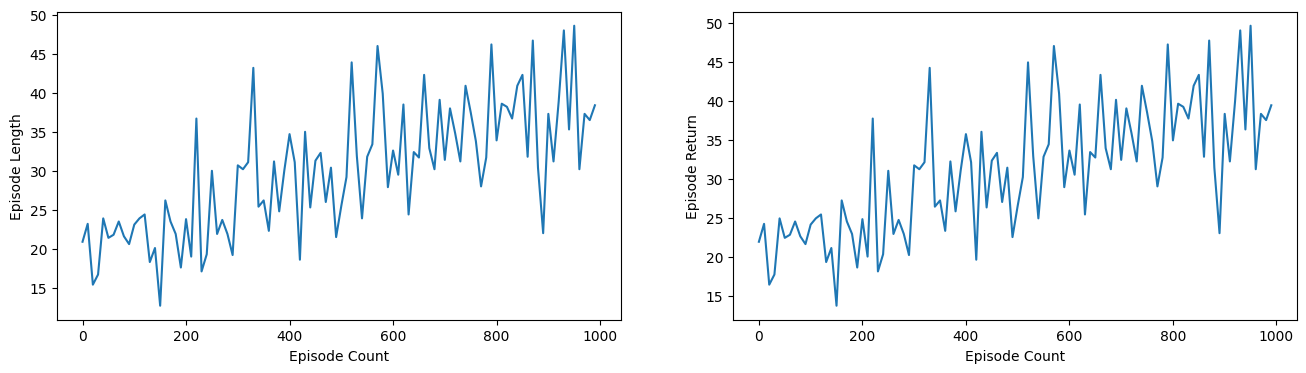

In [10]:
plot_stats(stats, window=10)